# Дерево решений — регрессор
Регрессионное дерево делит пространство признаков на области и прогнозирует среднее значение цели внутри каждой области: $\hat{y}(x)=\frac{1}{|R_m|}\sum_{i:x_i\in R_m} y_i$. Разбиения выбираются по минимизации суммы квадратов ошибок, эквивалентной уменьшению дисперсии в узлах: $\min_{s,j}\left[\sum_{i\in R_1(s,j)} (y_i-\bar{y}_{R_1})^2 + \sum_{i\in R_2(s,j)} (y_i-\bar{y}_{R_2})^2\right]$. Глубина и минимальный размер листа контролируют переобучение.


## Используемые библиотеки
Подключаем `numpy`, `pandas` для вычислений и работы с таблицами, `seaborn` и `matplotlib` для графиков, из `sklearn` — загрузчик `load_diabetes`, `train_test_split`, `DecisionTreeRegressor`, ансамбли (`RandomForestRegressor`, `GradientBoostingRegressor`), препроцессинг (`PolynomialFeatures`) и регрессионные метрики.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    validation_curve,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
PRIMARY_COLOR = "#1f77b4"
SECONDARY_COLOR = "#ff7f0e"
HEATMAP_CMAP = "coolwarm"


## Датасет: описание и частичная распечатка
Датасет **Diabetes** из `sklearn` — 442 пациента, 10 нормализованных числовых признаков: возраст, пол, ИМТ, среднее артериальное давление и шесть биохимических показателей крови. Целевая переменная — **target**: количественная мера прогрессирования диабета через год после начала исследования. Задача — регрессия. Датасет небольшой, что делает его удобным для демонстрации склонности дерева к переобучению.


In [3]:
diabetes = load_diabetes(as_frame=True)
data = diabetes.frame
print(f"Размерность: {data.shape}")
data.head()


Размерность: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Предварительная обработка
Отделяем признаки от целевой переменной. Разбиваем на train/test (80/20). Для улучшения качества создаем полиномиальные признаки 2-й степени (взаимодействия между признаками). Деревья инвариантны к масштабу признаков, но полиномиальные признаки позволяют дереву лучше моделировать нелинейные зависимости. Фиксируем `random_state=42` для воспроизводимости разбивки.


In [4]:
features = data.drop(columns=["target"])
target = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)


In [5]:
# Создаем полиномиальные признаки для улучшения качества
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Исходное количество признаков: {X_train.shape[1]}")
print(f"Количество признаков с полиномами: {X_train_poly.shape[1]}")

# Также сохраняем исходные данные для базового дерева
X_train_base = X_train.copy()
X_test_base = X_test.copy()


Исходное количество признаков: 10
Количество признаков с полиномами: 55


## Тепловая карта корреляций
Матрица корреляций для 10 признаков и целевой переменной. Видно, что **bmi** (ИМТ) и **s5** (уровень серотонина) наиболее коррелируют с прогрессированием диабета. Некоторые биохимические показатели коррелируют между собой — мультиколлинеарность не влияет на качество дерева, но полезна для интерпретации важности признаков.


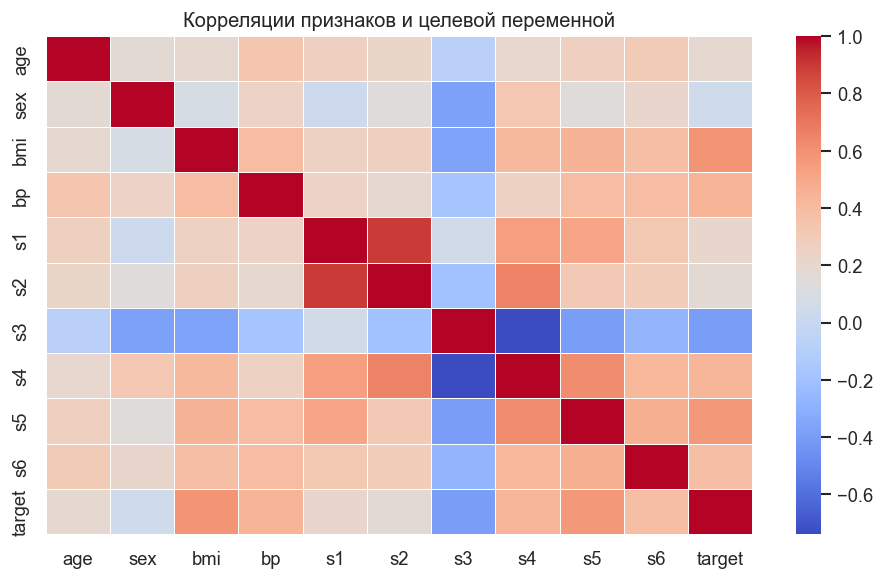

In [6]:
plt.figure(figsize=(8, 5))
correlation = data.corr()
sns.heatmap(correlation, annot=False, cmap=HEATMAP_CMAP, linewidths=0.5)
plt.title("Корреляции признаков и целевой переменной")
plt.tight_layout()
plt.show()


## Подбор гиперпараметров (RMSE, быстро)
Используем кросс-валидацию и оптимизируем **RMSE** (чем меньше, тем лучше). Для скорости берем компактную сетку.


In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


In [8]:
# Расширенная сетка для дерева решений
# Добавляем ccp_alpha (cost-complexity pruning) и min_impurity_decrease

tree_param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_impurity_decrease": [0.0, 0.001, 0.01],
}

tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

tree_search.fit(X_train_poly, y_train)
print("Лучшие параметры Decision Tree Regressor:", tree_search.best_params_)
print(f"Лучший CV RMSE: {-tree_search.best_score_:.2f}")


Лучшие параметры Decision Tree Regressor: {'max_depth': 3, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучший CV RMSE: 66.03


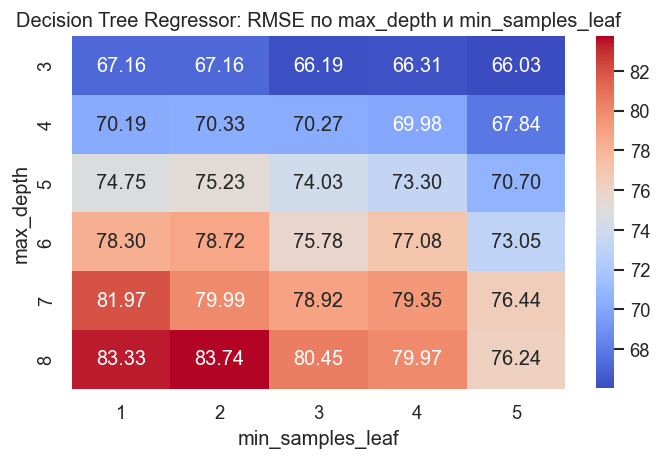

In [9]:
# Heatmap по двум параметрам при фиксированных лучших значениях других

tree_results = pd.DataFrame(tree_search.cv_results_)
best_split = tree_search.best_params_["min_samples_split"]
best_impurity = tree_search.best_params_["min_impurity_decrease"]

tree_subset = tree_results[
    (tree_results["param_min_samples_split"] == best_split) &
    (tree_results["param_min_impurity_decrease"] == best_impurity)
]

rmse_pivot = (-tree_subset.pivot_table(
    index="param_max_depth",
    columns="param_min_samples_leaf",
    values="mean_test_score",
))

plt.figure(figsize=(6, 4))
sns.heatmap(rmse_pivot, annot=True, fmt=".2f", cmap=HEATMAP_CMAP)
plt.title("Decision Tree Regressor: RMSE по max_depth и min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.tight_layout()
plt.show()


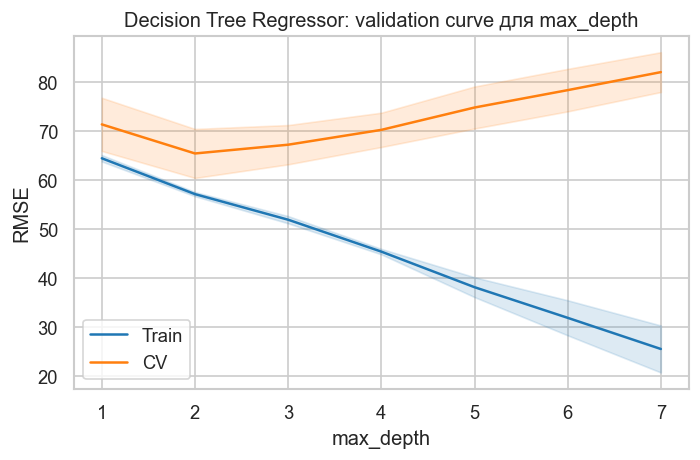

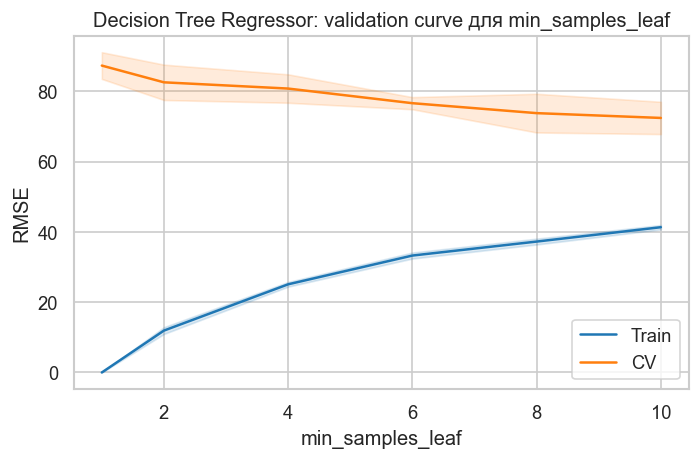

In [10]:
# Validation curves для дерева регрессии

def plot_validation_curve_reg(estimator, X, y, param_name, param_range, title):
    train_scores, valid_scores = validation_curve(
        estimator,
        X,
        y,
        param_name=param_name,
        param_range=param_range,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )
    train_mean = -train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = -valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(6, 4))
    plt.plot(param_range, train_mean, label="Train", color=PRIMARY_COLOR)
    plt.plot(param_range, valid_mean, label="CV", color=SECONDARY_COLOR)
    plt.fill_between(
        param_range,
        train_mean - train_std,
        train_mean + train_std,
        color=PRIMARY_COLOR,
        alpha=0.15,
    )
    plt.fill_between(
        param_range,
        valid_mean - valid_std,
        valid_mean + valid_std,
        color=SECONDARY_COLOR,
        alpha=0.15,
    )
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("RMSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_validation_curve_reg(
    DecisionTreeRegressor(random_state=42),
    X_train_poly,
    y_train,
    param_name="max_depth",
    param_range=[1, 2, 3, 4, 5, 6, 7],
    title="Decision Tree Regressor: validation curve для max_depth",
)

plot_validation_curve_reg(
    DecisionTreeRegressor(random_state=42),
    X_train_poly,
    y_train,
    param_name="min_samples_leaf",
    param_range=[1, 2, 4, 6, 8, 10],
    title="Decision Tree Regressor: validation curve для min_samples_leaf",
)


## Обучение модели
Используем лучшую модель из подбора гиперпараметров. Ограничение глубины и минимального размера листа снижает переобучение и улучшает обобщающую способность.


In [11]:
model = tree_search.best_estimator_


## Прогнозы модели
Три регрессионные метрики:
- **MAE** — среднее отклонение в единицах целевой переменной;
- **RMSE** — штрафует крупные ошибки сильнее MAE;
- **R²** — 1.0 идеально, значения 0.4–0.6 типичны для дерева с ограниченной глубиной на этом датасете.


In [12]:
y_pred = model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Decision Tree Regressor Metrics")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.3f}")


Decision Tree Regressor Metrics
MAE:  47.53
RMSE: 59.43
R2:   0.333


## Графики выходных результатов
**График 1. Факт vs Прогноз.** Ступенчатый характер точек — особенность дерева: оно предсказывает конечное число уникальных значений (по одному на лист). Хорошая модель — точки вдоль диагонали.

**График 2. Важность признаков (Feature Importances).** Показывает вклад каждого признака в снижение MSE при разбиениях. **bmi** и **s5** должны лидировать — это соответствует корреляционному анализу.


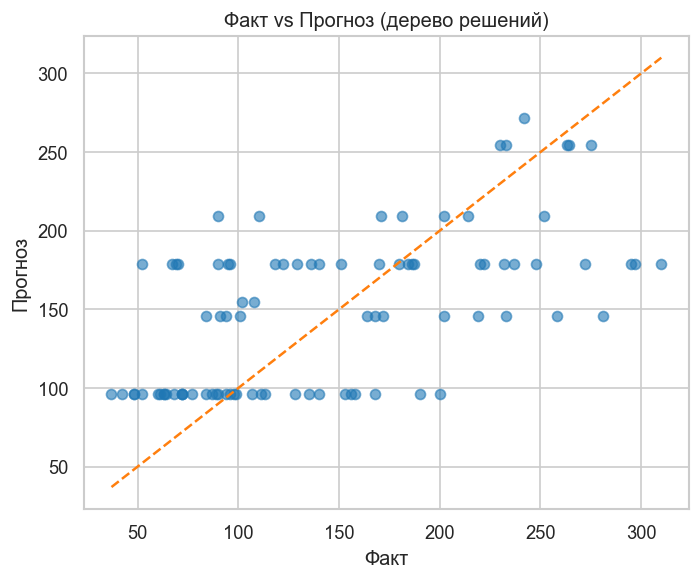

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color=PRIMARY_COLOR)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color=SECONDARY_COLOR,
    linestyle="--",
)
plt.xlabel("Факт")
plt.ylabel("Прогноз")
plt.title("Факт vs Прогноз (дерево решений)")
plt.tight_layout()
plt.show()


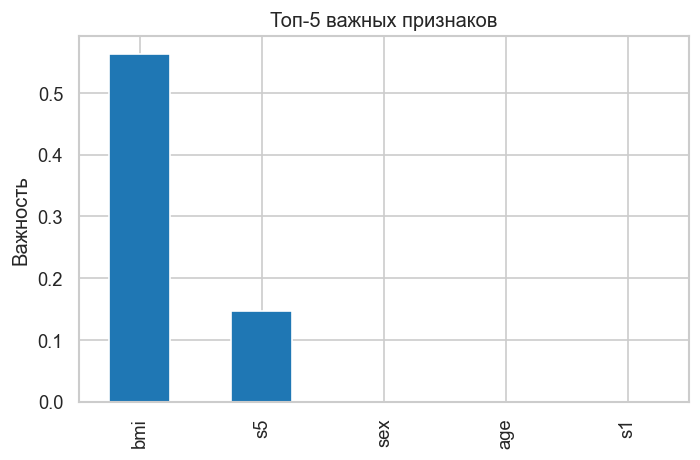

In [14]:
# Используем исходные имена признаков для первых 10
feature_names = list(features.columns)
importance = pd.Series(model.feature_importances_[:len(feature_names)], index=feature_names)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(6, 4))
importance.head(5).plot(kind="bar", color=PRIMARY_COLOR)
plt.ylabel("Важность")
plt.title("Топ-5 важных признаков")
plt.tight_layout()
plt.show()


## Сравнение с ансамблевыми методами
Для улучшения качества сравниваем одиночное дерево с **Random Forest** (усреднение множества деревьев снижает переобучение) и **Gradient Boosting** (последовательное исправление ошибок предыдущих деревьев). Ансамбли обычно дают лучшие метрики на тестовой выборке.


In [15]:
# Random Forest - подбор гиперпараметров
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [4, 5, 6, 7],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", 0.5, 0.7],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

rf_search.fit(X_train_poly, y_train)
print("Лучшие параметры Random Forest:", rf_search.best_params_)
print(f"Лучший CV RMSE: {-rf_search.best_score_:.2f}")

rf_model = rf_search.best_estimator_
rf_pred = rf_model.predict(X_test_poly)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Metrics")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2:   {rf_r2:.3f}")


Лучшие параметры Random Forest: {'max_depth': 7, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 200}
Лучший CV RMSE: 58.07

Random Forest Metrics
MAE:  43.71
RMSE: 53.05
R2:   0.469


In [16]:
# Gradient Boosting - подбор гиперпараметров
gb_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [1, 2, 3],
    "subsample": [0.8, 1.0],
}

gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

gb_search.fit(X_train_poly, y_train)
print("Лучшие параметры Gradient Boosting:", gb_search.best_params_)
print(f"Лучший CV RMSE: {-gb_search.best_score_:.2f}")

gb_model = gb_search.best_estimator_
gb_pred = gb_model.predict(X_test_poly)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("\nGradient Boosting Metrics")
print(f"MAE:  {gb_mae:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"R2:   {gb_r2:.3f}")


Лучшие параметры Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 50, 'subsample': 0.8}
Лучший CV RMSE: 58.91

Gradient Boosting Metrics
MAE:  46.50
RMSE: 56.12
R2:   0.406


## Сравнение всех моделей
Сводная таблица метрик трех алгоритмов и визуализация распределения ошибок. Ансамбли должны показать меньше RMSE и выше R².


In [17]:
# Сводная таблица метрик
metrics_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, rf_mae, gb_mae],
    "RMSE": [rmse, rf_rmse, gb_rmse],
    "R2": [r2, rf_r2, gb_r2],
})

print("\n=== Сравнение моделей ===")
print(metrics_df.to_string(index=False))



=== Сравнение моделей ===
            Model       MAE      RMSE       R2
    Decision Tree 47.534536 59.432345 0.333314
    Random Forest 43.707847 53.051415 0.468786
Gradient Boosting 46.498683 56.117602 0.405607


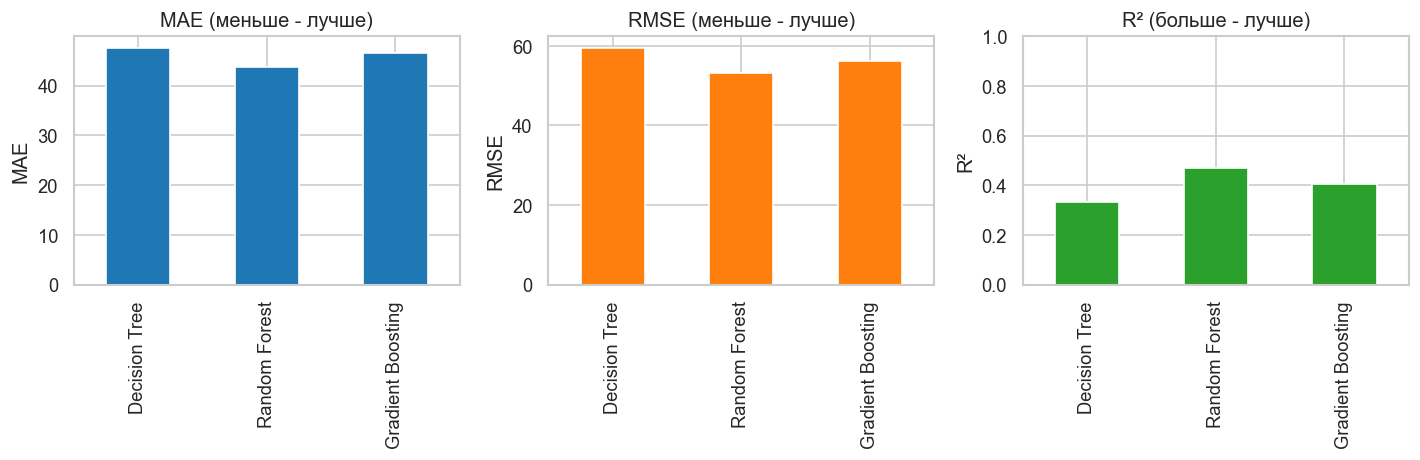

In [18]:
# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics_df.plot(x="Model", y="MAE", kind="bar", ax=axes[0], color=PRIMARY_COLOR, legend=False)
axes[0].set_title("MAE (меньше - лучше)")
axes[0].set_ylabel("MAE")
axes[0].set_xlabel("")

metrics_df.plot(x="Model", y="RMSE", kind="bar", ax=axes[1], color=SECONDARY_COLOR, legend=False)
axes[1].set_title("RMSE (меньше - лучше)")
axes[1].set_ylabel("RMSE")
axes[1].set_xlabel("")

metrics_df.plot(x="Model", y="R2", kind="bar", ax=axes[2], color="#2ca02c", legend=False)
axes[2].set_title("R² (больше - лучше)")
axes[2].set_ylabel("R²")
axes[2].set_xlabel("")
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()


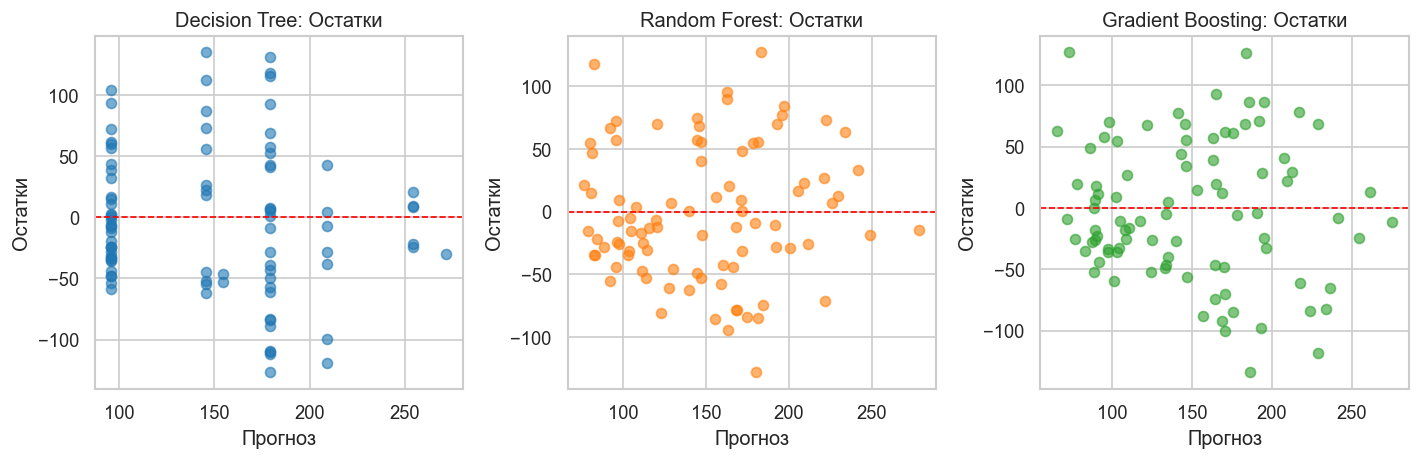

In [19]:
# Распределение остатков для всех моделей
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

residuals_dt = y_test - y_pred
residuals_rf = y_test - rf_pred
residuals_gb = y_test - gb_pred

axes[0].scatter(y_pred, residuals_dt, alpha=0.6, color=PRIMARY_COLOR)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Decision Tree: Остатки")
axes[0].set_xlabel("Прогноз")
axes[0].set_ylabel("Остатки")

axes[1].scatter(rf_pred, residuals_rf, alpha=0.6, color=SECONDARY_COLOR)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Random Forest: Остатки")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остатки")

axes[2].scatter(gb_pred, residuals_gb, alpha=0.6, color="#2ca02c")
axes[2].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Gradient Boosting: Остатки")
axes[2].set_xlabel("Прогноз")
axes[2].set_ylabel("Остатки")

plt.tight_layout()
plt.show()
